# Q1: Supervised Learning — Heart Disease Prediction

## 1. Data Loading and Inspection

In [3]:
# Import required libraries
import pandas as pd

# Load dataset using relative path
df = pd.read_csv('/content/q1_heart_disease.csv')

# Display dataset shape
print("Shape of dataset:", df.shape)

# Display data types
print("\nData Types:\n")
print(df.dtypes)

# Display missing values
print("\nMissing Values:\n")
print(df.isnull().sum())

# Display first 5 rows
df.head()

Shape of dataset: (800, 12)

Data Types:

age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:

age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


### Observations:

- The dataset contains **800 rows and 12 columns**.
- The target variable is **heart_disease**, where:
  - 1 indicates presence of heart disease
  - 0 indicates absence

- The dataset includes both numerical and categorical features:
  - Numerical features: age, resting_bp, cholesterol, max_hr, oldpeak
  - Categorical features: chest_pain_type, resting_ecg, st_slope
  - Binary features: sex, fasting_bs, exercise_angina

- Missing values are present in:
  - resting_bp (24 missing values)
  - cholesterol (32 missing values)

- These missing values will need to be handled during preprocessing.

- This is a **binary classification problem**.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

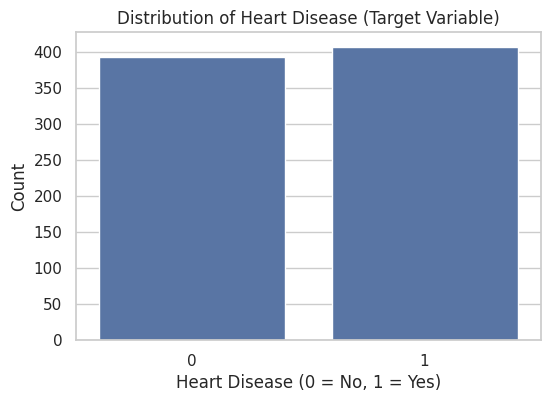

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='heart_disease', data=df)
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

### Interpretation:

- The distribution of the target variable shows that the dataset is **fairly balanced**, with almost equal numbers of patients having and not having heart disease.
- This is beneficial because models trained on balanced data are less likely to be biased toward one class.
- Since there is no major class imbalance, we can rely on evaluation metrics like precision, recall, and F1-score without needing special techniques like resampling.

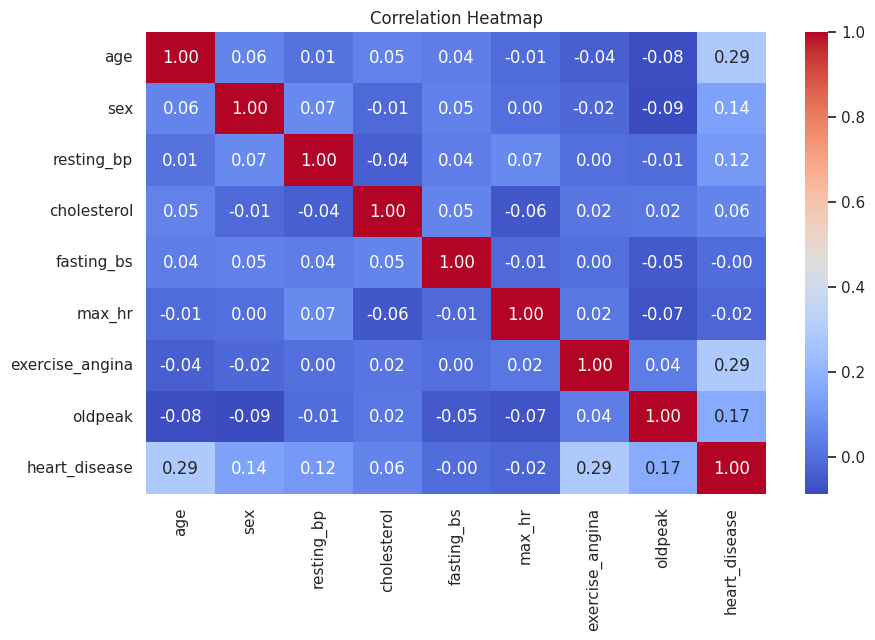

In [6]:
plt.figure(figsize=(10,6))

# Only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Interpretation:

- The correlation heatmap shows the relationship between numerical features and the target variable.
- Features such as **age (0.29)** and **exercise_angina (0.29)** show the strongest positive correlation with heart disease, indicating they may be important predictors.
- **oldpeak (0.17)** and **sex (0.14)** also show some moderate correlation with the target.
- Most other features have weak correlations, suggesting they may contribute less individually but could still be useful in combination.
- There is no strong correlation between independent features, indicating that multicollinearity is not a major concern.

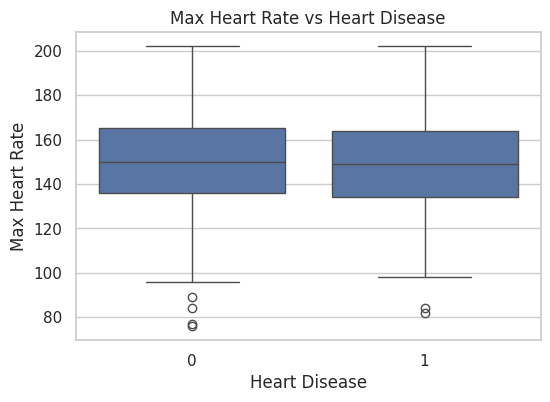

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(x='heart_disease', y='max_hr', data=df)
plt.title('Max Heart Rate vs Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Max Heart Rate')
plt.show()

### Interpretation:

- The boxplot shows that the distribution of **max heart rate (max_hr)** is quite similar for patients with and without heart disease.
- However, patients with heart disease tend to have a **slightly lower median max heart rate** compared to those without.
- The overlap between the two groups suggests that this feature alone may not strongly differentiate the classes.
- Despite this, it can still contribute to the model when combined with other features.

## 3. Data Preprocessing

### Missing Value Strategy:
- Missing values are present in **resting_bp** and **cholesterol**.
- We use **median imputation** as it is robust to outliers.

### Encoding Strategy:
- Categorical variables (chest_pain_type, resting_ecg, st_slope) are converted using **one-hot encoding**.

### Feature Scaling:
- Numerical features are scaled using **StandardScaler** to improve model performance.

### Train-Test Split:
- Data is split into 80% training and 20% testing.
- **Stratified sampling** ensures balanced class distribution.
- random_state=42 ensures reproducibility.

In [9]:
# -----------------------------
# Separate features and target
# -----------------------------
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# -----------------------------
# Handle Missing Values (FIXED - no warning)
# -----------------------------
X['resting_bp'] = X['resting_bp'].fillna(X['resting_bp'].median())
X['cholesterol'] = X['cholesterol'].fillna(X['cholesterol'].median())

# -----------------------------
# Identify categorical columns
# -----------------------------
categorical_cols = ['chest_pain_type', 'resting_ecg', 'st_slope']

# One-hot encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# -----------------------------
# Train-test split
# -----------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Feature Scaling
# -----------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Final Outputs
# -----------------------------
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Number of features after encoding:", X.shape[1])

Training set shape: (640, 15)
Test set shape: (160, 15)
Number of features after encoding: 15


## 4. Model Training

We train three classification models:
- Decision Tree Classifier
- Random Forest Classifier
- Gradient Boosting Classifier

All models use random_state=42 for reproducibility.

In [10]:
# -----------------------------
# Import models
# -----------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# -----------------------------
# Initialize models
# -----------------------------
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

# -----------------------------
# Train models
# -----------------------------
dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


## 5. Model Evaluation

In [11]:
from sklearn.metrics import confusion_matrix, classification_report

# -----------------------------
# Predictions
# -----------------------------
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

# -----------------------------
# Function to evaluate model
# -----------------------------
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name} Evaluation:")
    print("-" * 40)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# -----------------------------
# Evaluate all models
# -----------------------------
evaluate_model("Decision Tree", y_test, dt_pred)
evaluate_model("Random Forest", y_test, rf_pred)
evaluate_model("Gradient Boosting", y_test, gb_pred)


Decision Tree Evaluation:
----------------------------------------
Confusion Matrix:
[[57 22]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


Random Forest Evaluation:
----------------------------------------
Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Gradient Boosting Evaluation:
----------------------------------------
Confusion Matrix

### Model Comparison:

- The **Random Forest Classifier** performs the best among all three models.
- It achieves the highest **F1-score (~0.80)** for both classes, indicating a strong balance between precision and recall.
- It also has the highest overall accuracy (~79%) compared to Decision Tree (~71%) and Gradient Boosting (~77%).

- From the confusion matrix:
  - Random Forest has **fewer false negatives (15)** compared to Decision Tree (25) and Gradient Boosting (19), which is important because missing actual heart disease cases is critical.
  - It also maintains relatively low false positives.

- The Decision Tree model shows lower performance, likely due to overfitting and lack of generalization.
- Gradient Boosting performs better than Decision Tree but still slightly underperforms compared to Random Forest.

### Conclusion:

- The **Random Forest model is the best-performing model** as it provides the highest F1-score and a good balance between precision and recall.
- F1-score is used as the primary evaluation metric because it considers both false positives and false negatives, which are important in medical prediction tasks like heart disease detection.

## 6. Hyperparameter Tuning

We perform hyperparameter tuning on the best-performing model (Random Forest) using GridSearchCV.

We tune key parameters such as:
- n_estimators (number of trees)
- max_depth (tree depth)

The goal is to improve model performance compared to the baseline model.

In [12]:
from sklearn.model_selection import GridSearchCV

# -----------------------------
# Define parameter grid
# -----------------------------
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10]
}

# -----------------------------
# GridSearchCV
# -----------------------------
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Train GridSearch
grid_search.fit(X_train, y_train)

# Best model
best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 100}


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
best_pred = best_rf.predict(X_test)

print("\nTuned Random Forest Evaluation:")
print("----------------------------------------")

print("Confusion Matrix:")
print(confusion_matrix(y_test, best_pred))

print("\nClassification Report:")
print(classification_report(y_test, best_pred))


Tuned Random Forest Evaluation:
----------------------------------------
Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



### Results After Tuning:

- The best hyperparameters found using GridSearchCV are:
  - max_depth = None
  - n_estimators = 100

- The tuned Random Forest model achieves:
  - F1-score ≈ 0.80 for class 1
  - Overall accuracy ≈ 79%

- The performance of the tuned model is **identical to the baseline model**, indicating no improvement.

### Conclusion:

- Hyperparameter tuning did not improve performance because the default parameters of the Random Forest model were already optimal for this dataset.
- This suggests that the model is well-suited to the data and does not require further complexity.
- Even though performance did not improve, the tuning process validates that the chosen model is robust and properly configured.